<a href="https://colab.research.google.com/github/renu-kg/PRODIGY_GA_02/blob/main/Task_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install necessary libraries
!pip install diffusers transformers accelerate torch --quiet
!pip install invisible_watermark transformers accelerate safetensors --quiet
!pip install ftfy==6.1.1 # Install a specific version of ftfy for better compatibility if needed

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.9 MB/s eta 0:00:00


In [2]:
import torch
from diffusers import DiffusionPipeline
from IPython.display import display

# Load the Stable Diffusion model
# Using safety_checker=None to potentially avoid compatibility issues with it

# Load the base SDXL model for the initial generation
# Enable sequential CPU offloading for maximum memory saving
base = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)
base.enable_sequential_cpu_offload()


# Load the refiner model for the finishing touches
# Enable sequential CPU offloading for the refiner as well
refiner = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-refiner-1.0",
    text_encoder_2=base.text_encoder_2,
    vae=base.vae,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
)
refiner.enable_sequential_cpu_offload()

print("SDXL models are loaded and ready using sequential CPU offloading.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

vae_1_0/diffusion_pytorch_model.fp16.saf(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/4.52G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

SDXL models are loaded and ready using sequential CPU offloading.



 Generating image for prompt: 'In the style of Van Gogh — starry sky over a peaceful village, oil painting brush texture'


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

 Image generated and refined successfully!


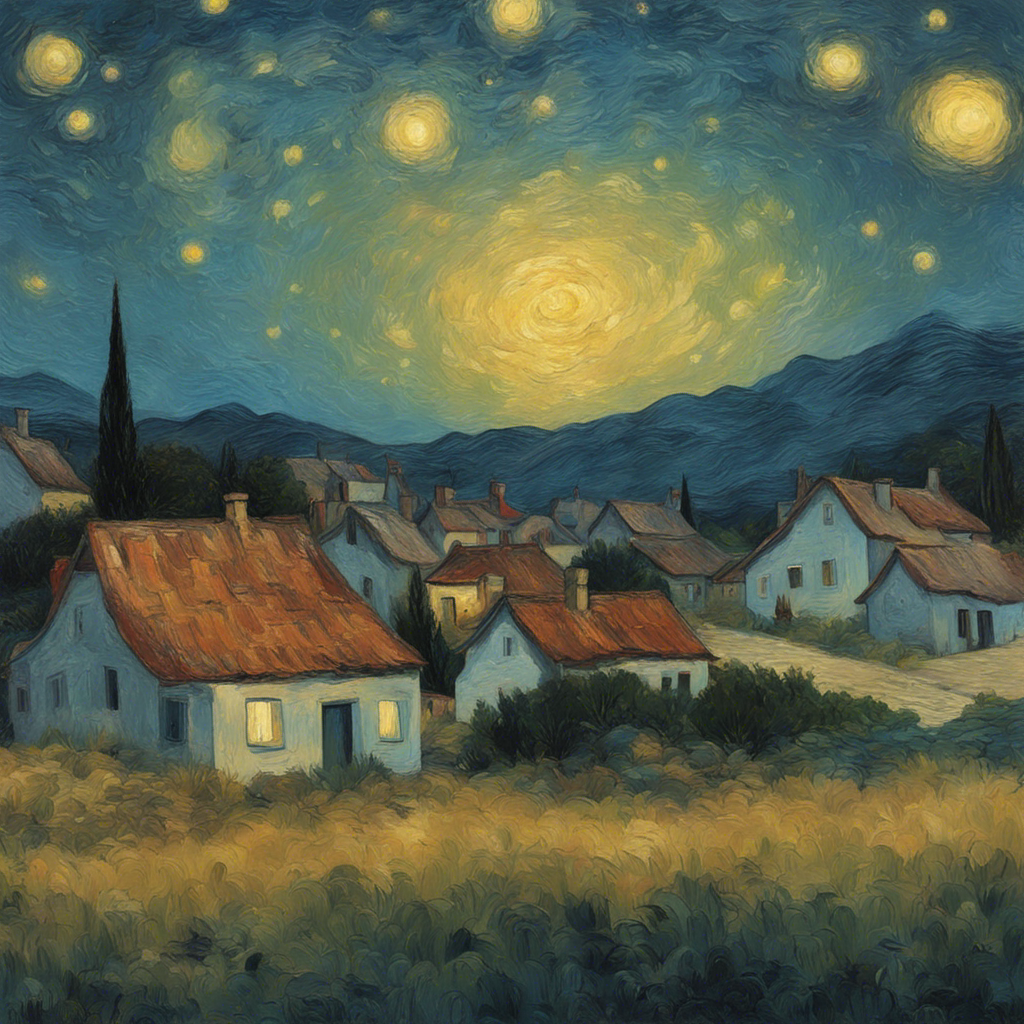

In [4]:
prompt = "In the style of Van Gogh — starry sky over a peaceful village, oil painting brush texture"

print(f"\n Generating image for prompt: '{prompt}'")

# --- Step 4: Generate and Refine the Image ---
# We run the base model first, then pass its output to the refiner.
# We set `output_type="latent"` to pass the raw data to the refiner without saving an intermediate image.

# Enable attention slicing and VAE slicing for memory efficiency
base.enable_attention_slicing()
base.enable_vae_slicing()
refiner.enable_attention_slicing()
refiner.enable_vae_slicing()


image_latents = base(
    prompt=prompt,
    output_type="latent",
).images

# The refiner model adds the final high-quality details.
image = refiner(
    prompt=prompt,
    image=image_latents,
).images[0]

print(" Image generated and refined successfully!")
display(image)